# Hierarchical Clustering

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

## Imports

In [1]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Scipy imports for Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist

# Sklearn imports
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [2]:
tracks_df = pd.read_csv("../datasets/tracks_cleaned.csv")

## Features Selection

In [3]:
selected_features = [
    # linguistic / lyrics
    # 'n_tokens',
    # 'swear_IT',
    # 'lexical_density',

    # audio features
    # 'bpm',
    'centroid',
    'loudness',
    'spectral_complexity',
    # 'flux',
    'rolloff',

    # popularity
    'popularity',
    # 'relative_popularity',

    # time-related
    # 'season_autumn', 'season_spring', 'season_summer', 'season_winter',

    # engineered features
    # 'has_collaboration',
    'aggressiveness',
    # 'song_age',
    # 'duration_sec'
]

In [4]:
#Extract feature matrix
X = tracks_df[selected_features].copy()

## Preprocessing (Scaling & Normalization)

In [5]:
# Check for NaN values
print(X.isna().sum())

centroid               0
loudness               0
spectral_complexity    0
rolloff                0
popularity             0
aggressiveness         0
dtype: int64


**Normalization**: We tried to normalize using both z-score and min-max, to see which one works best for different algorithms.

In [6]:
# Scale the features (z-score)
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_zscore = std_scaler.fit_transform(X)

In [7]:
# Scale the features (Min-Max)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

In [8]:
X_scaled = X_zscore

### Study of Clustering Parameters

In [9]:
def analyze_hierarchical_method(X_scaled, X_original, method, k_range=range(2, 7)):
    """
    Complete pipeline for Hierarchical Clustering Analysis:
    1. Plots Dendrogram
    2. Grid Search for K (Silhouette & Distribution)
    3. Visualizes Best K (PCA)
    4. Characterizes Best K (Feature Means)
    """
    
    # --- 1. Dendrogram ---
    plt.figure(figsize=(12, 5))
    plt.title(f"Dendrogram ({method} linkage)")
    Z = linkage(X_scaled, method=method, metric='euclidean')
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., show_contracted=False)
    plt.xlabel("Cluster Size / ID")
    plt.ylabel("Distance")
    plt.show()

    # --- 2. Tuning K (Silhouette & Distribution) ---
    best_k = 0
    best_score = -1
    best_labels = None
    results = []

    for k in k_range:
        hc = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = hc.fit_predict(X_scaled)
        
        score = silhouette_score(X_scaled, labels)
        counts = pd.Series(labels).value_counts().sort_index()
        
        results.append({
            'k': k,
            'silhouette': score,
            'counts': counts,
            'labels': labels
        })
        
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

        # --- PRINT DISTRIBUTION + SILHOUETTE ---
        print(f"\nClustering k = {k}:")
        print(f"  Silhouette score = {score:.4f}")
        for cluster_id, count in counts.items():
            print(f"  Cluster {cluster_id}: {count} samples")

    # --- Silhouette Score Plot (ALONE) ---
    results_df = pd.DataFrame({
        'k': [r['k'] for r in results],
        'silhouette': [r['silhouette'] for r in results]
    })

    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=results_df,
        x='k',
        y='silhouette',
        marker='o',
        color='purple'
    )
    plt.title(f'Silhouette Score vs K ({method})')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

    # --- Cluster Distribution Plot (ALONE) ---
    dist_data = []
    for res in results:
        for c_id, count in res['counts'].items():
            dist_data.append({
                'k': res['k'],
                'cluster': c_id,
                'count': count
            })
    dist_df = pd.DataFrame(dist_data)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=dist_df,
        x='k',
        y='count',
        hue='cluster',
        palette='viridis'
    )
    plt.title(f'Cluster Size Distribution by K ({method})')
    plt.tight_layout()
    plt.show()

    # --- Best K Summary ---
    best_res = next(r for r in results if r['k'] == best_k)
    print(f"\n--> BEST CONFIGURATION")
    print(f"Clustering k = {best_k}:")
    print(f"  Silhouette score = {best_score:.4f}")
    for cluster_id, count in best_res['counts'].items():
        print(f"  Cluster {cluster_id}: {count} samples")

    # --- 3. PCA Visualization ---
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=best_labels,
        cmap='viridis',
        s=20,
        alpha=0.6
    )
    plt.title(f"{method.capitalize()} Linkage (k={best_k}) - PCA Projection")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(scatter, label='Cluster Label')
    plt.show()

    # --- 4. Cluster Characterization ---
    df_analysis = X_original.copy()
    df_analysis['cluster'] = best_labels
    
    cluster_means = df_analysis.groupby('cluster').mean()
    global_means = X_original.mean()
    
    print("\n--- CLUSTER PROFILES (Original Scale) ---")
    print(cluster_means)
    
    print("\n--- DEVIATION FROM GLOBAL MEAN ---")
    print(cluster_means - global_means)
    
    return results_df

### Ward Linkage

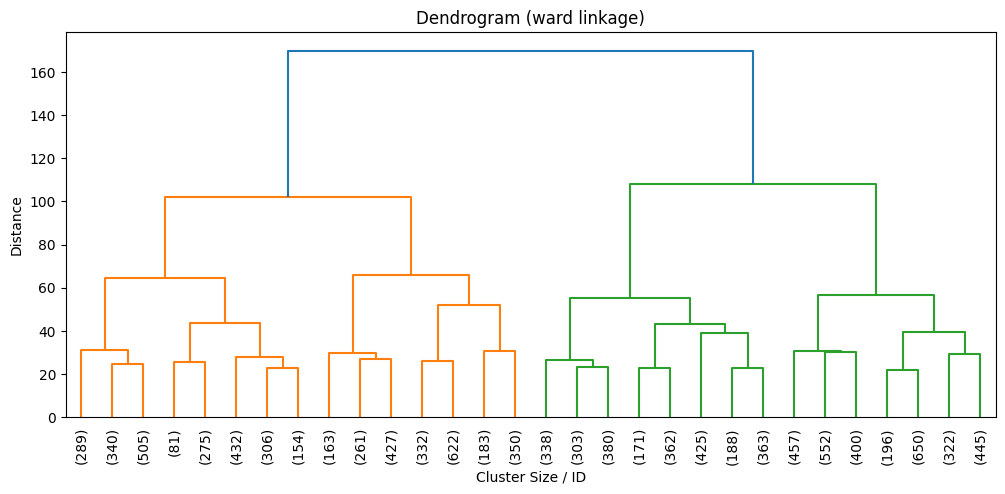


Clustering k = 2:
  Silhouette score = 0.1970
  Cluster 0: 5552 samples
  Cluster 1: 4720 samples

Clustering k = 3:
  Silhouette score = 0.1220
  Cluster 0: 4720 samples
  Cluster 1: 3022 samples
  Cluster 2: 2530 samples

Clustering k = 4:
  Silhouette score = 0.1311
  Cluster 0: 2338 samples
  Cluster 1: 2382 samples
  Cluster 2: 2530 samples
  Cluster 3: 3022 samples

Clustering k = 5:
  Silhouette score = 0.1174
  Cluster 0: 2382 samples
  Cluster 1: 3022 samples
  Cluster 2: 2530 samples
  Cluster 3: 1487 samples
  Cluster 4: 851 samples

Clustering k = 6:
  Silhouette score = 0.1158
  Cluster 0: 3022 samples
  Cluster 1: 1487 samples
  Cluster 2: 2530 samples
  Cluster 3: 1248 samples
  Cluster 4: 851 samples
  Cluster 5: 1134 samples


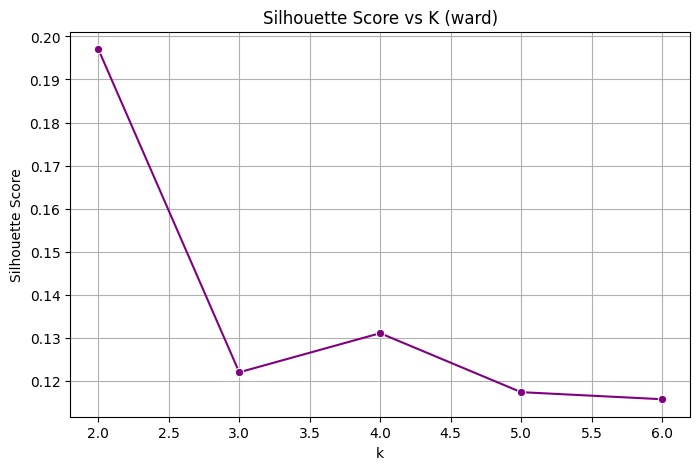

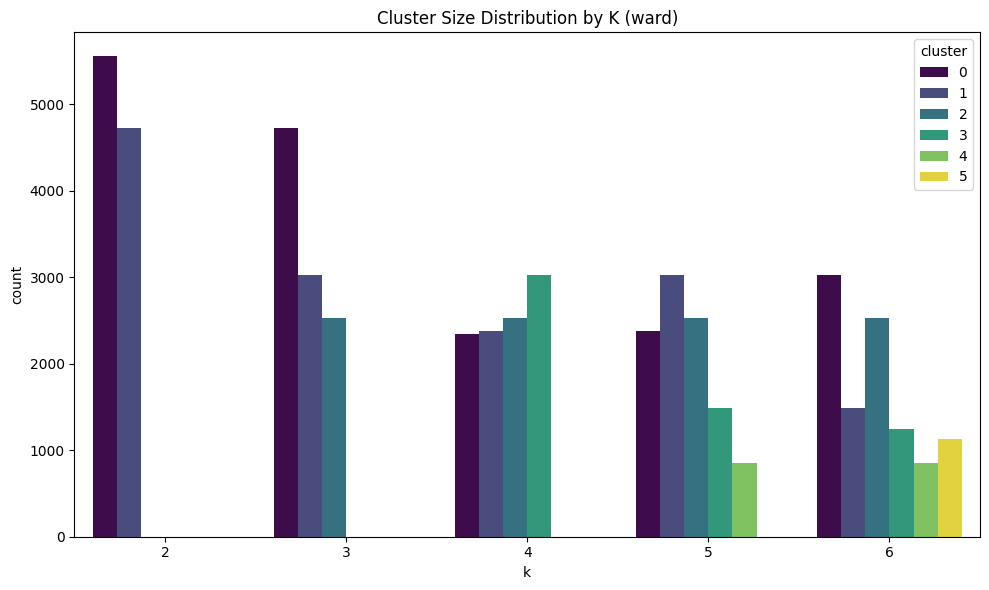


--> BEST CONFIGURATION
Clustering k = 2:
  Silhouette score = 0.1970
  Cluster 0: 5552 samples
  Cluster 1: 4720 samples


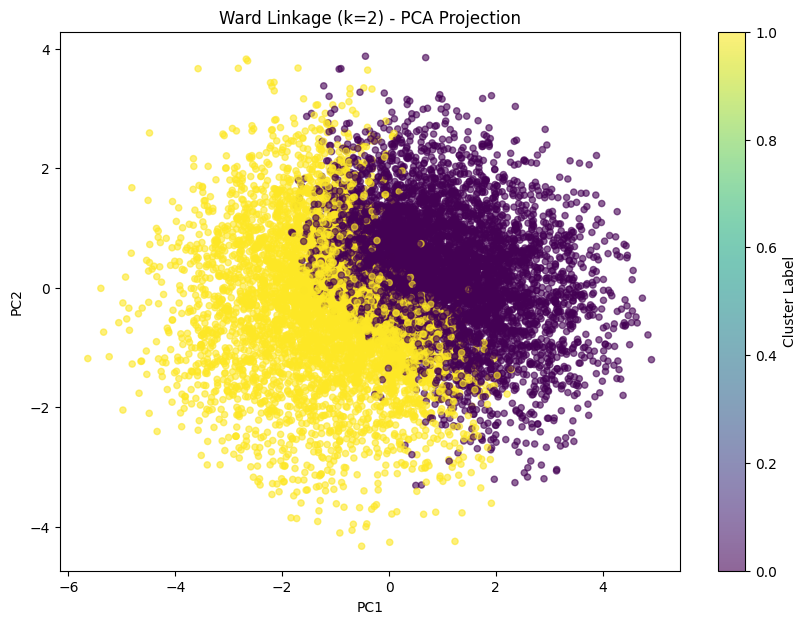


--- CLUSTER PROFILES (Original Scale) ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0        0.150793  28.684830            32.261647  6.447996   33.142111   
1        0.124997  20.099988            23.020432  6.091544   32.742161   

         aggressiveness  
cluster                  
0              0.312834  
1             -0.286217  

--- DEVIATION FROM GLOBAL MEAN ---
         centroid  loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                  
0        0.011853  3.944748             4.246353  0.163790    0.183778   
1       -0.013943 -4.640094            -4.994862 -0.192662   -0.216172   

         aggressiveness  
cluster                  
0              0.275265  
1             -0.323786  


In [10]:
ward_results = analyze_hierarchical_method(X_scaled, X, method='ward')

### Single Linkage

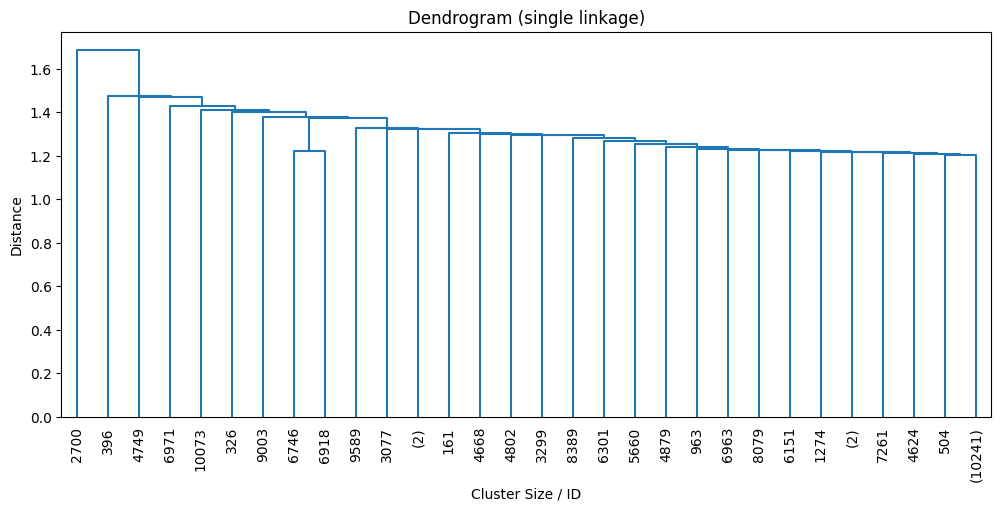


Clustering k = 2:
  Silhouette score = 0.3925
  Cluster 0: 10271 samples
  Cluster 1: 1 samples

Clustering k = 3:
  Silhouette score = 0.2825
  Cluster 0: 10270 samples
  Cluster 1: 1 samples
  Cluster 2: 1 samples

Clustering k = 4:
  Silhouette score = 0.2141
  Cluster 0: 10269 samples
  Cluster 1: 1 samples
  Cluster 2: 1 samples
  Cluster 3: 1 samples

Clustering k = 5:
  Silhouette score = 0.1920
  Cluster 0: 10268 samples
  Cluster 1: 1 samples
  Cluster 2: 1 samples
  Cluster 3: 1 samples
  Cluster 4: 1 samples

Clustering k = 6:
  Silhouette score = 0.1600
  Cluster 0: 10267 samples
  Cluster 1: 1 samples
  Cluster 2: 1 samples
  Cluster 3: 1 samples
  Cluster 4: 1 samples
  Cluster 5: 1 samples


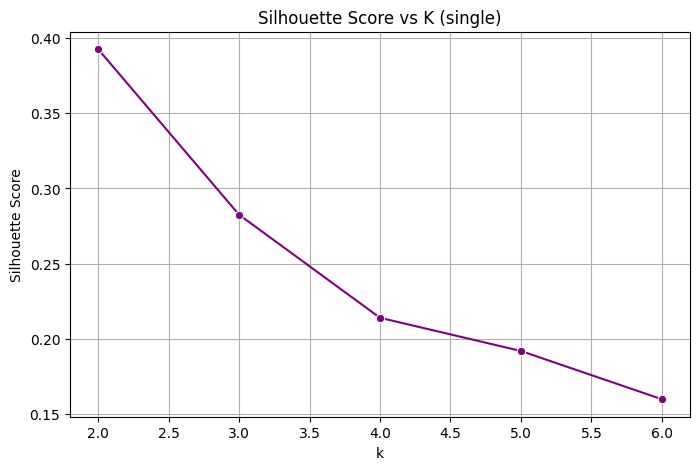

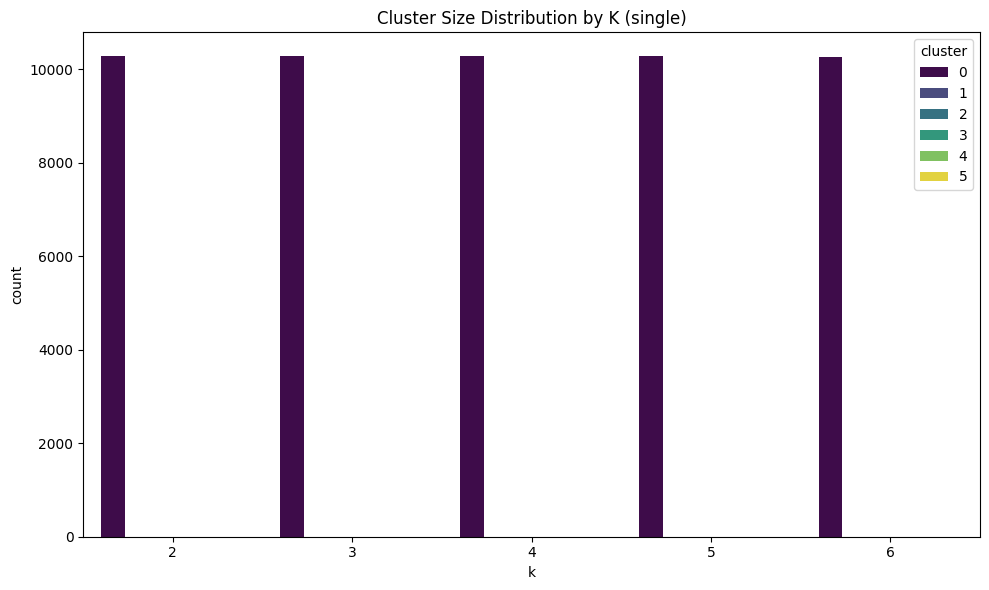


--> BEST CONFIGURATION
Clustering k = 2:
  Silhouette score = 0.3925
  Cluster 0: 10271 samples
  Cluster 1: 1 samples


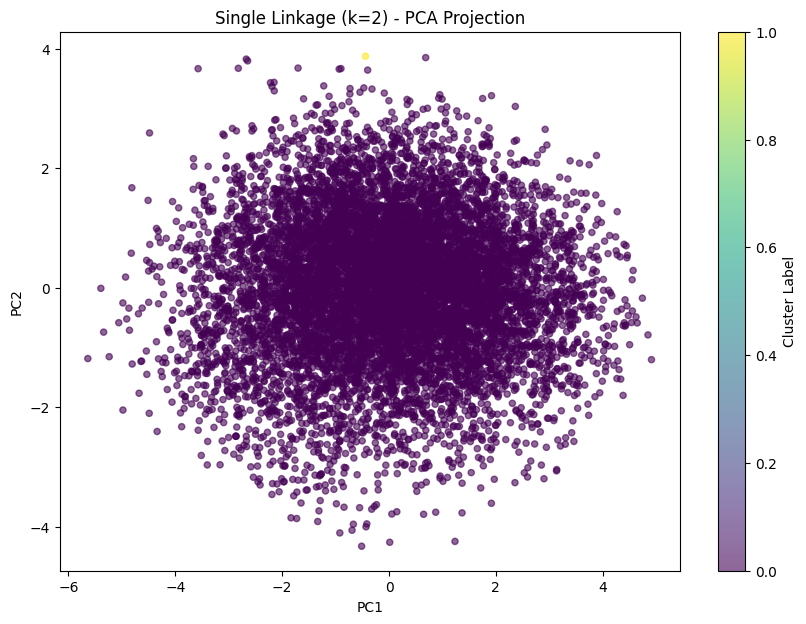


--- CLUSTER PROFILES (Original Scale) ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0        0.138945  24.737942            28.013229  6.284260   32.961055   
1        0.077600  46.717400            49.233200  5.725461    5.000000   

         aggressiveness  
cluster                  
0              0.037617  
1             -0.451525  

--- DEVIATION FROM GLOBAL MEAN ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0        0.000006  -0.002140            -0.002066  0.000054    0.002722   
1       -0.061339  21.977318            21.217905 -0.558745  -27.958333   

         aggressiveness  
cluster                  
0              0.000048  
1             -0.489095  


In [11]:
single_results = analyze_hierarchical_method(X_scaled, X, method='single')

### Complete Linkage

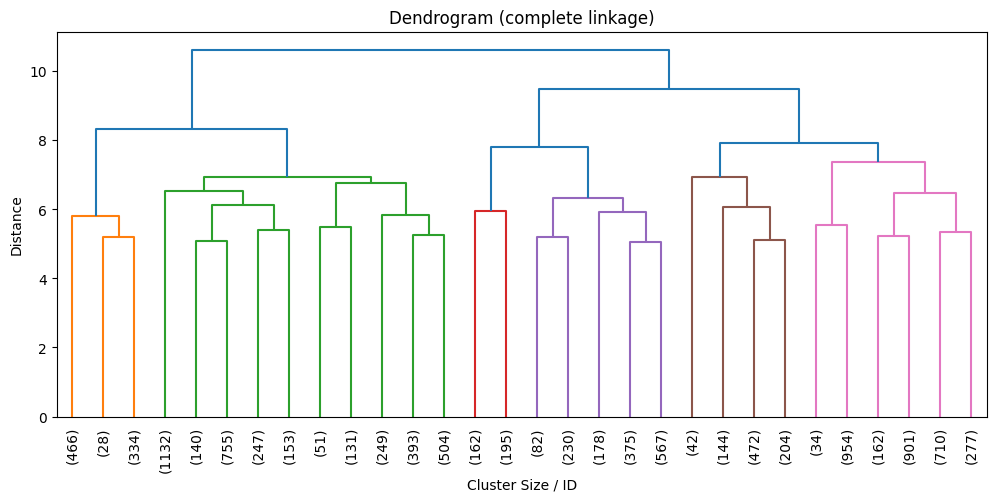


Clustering k = 2:
  Silhouette score = 0.1951
  Cluster 0: 5689 samples
  Cluster 1: 4583 samples

Clustering k = 3:
  Silhouette score = 0.1471
  Cluster 0: 4583 samples
  Cluster 1: 3900 samples
  Cluster 2: 1789 samples

Clustering k = 4:
  Silhouette score = 0.0873
  Cluster 0: 3900 samples
  Cluster 1: 3755 samples
  Cluster 2: 1789 samples
  Cluster 3: 828 samples

Clustering k = 5:
  Silhouette score = 0.0497
  Cluster 0: 1789 samples
  Cluster 1: 3755 samples
  Cluster 2: 3038 samples
  Cluster 3: 828 samples
  Cluster 4: 862 samples

Clustering k = 6:
  Silhouette score = 0.0471
  Cluster 0: 3038 samples
  Cluster 1: 3755 samples
  Cluster 2: 1432 samples
  Cluster 3: 828 samples
  Cluster 4: 862 samples
  Cluster 5: 357 samples


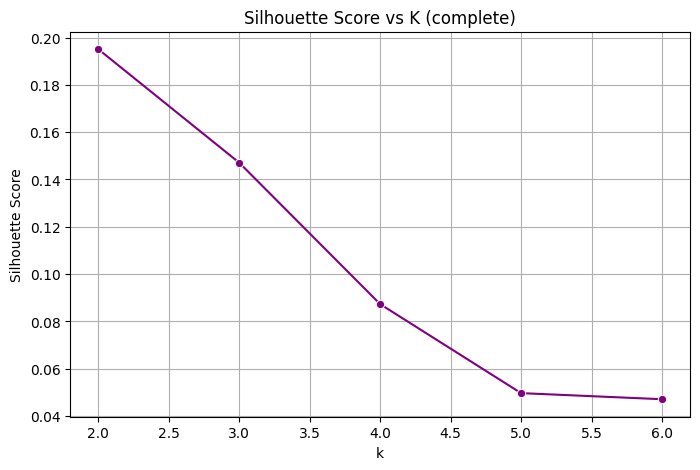

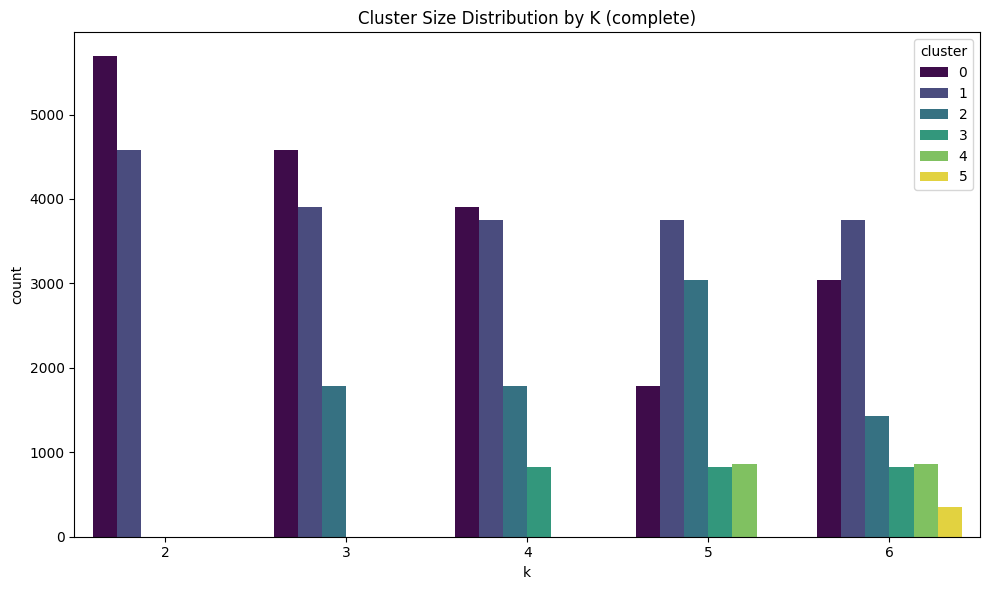


--> BEST CONFIGURATION
Clustering k = 2:
  Silhouette score = 0.1951
  Cluster 0: 5689 samples
  Cluster 1: 4583 samples


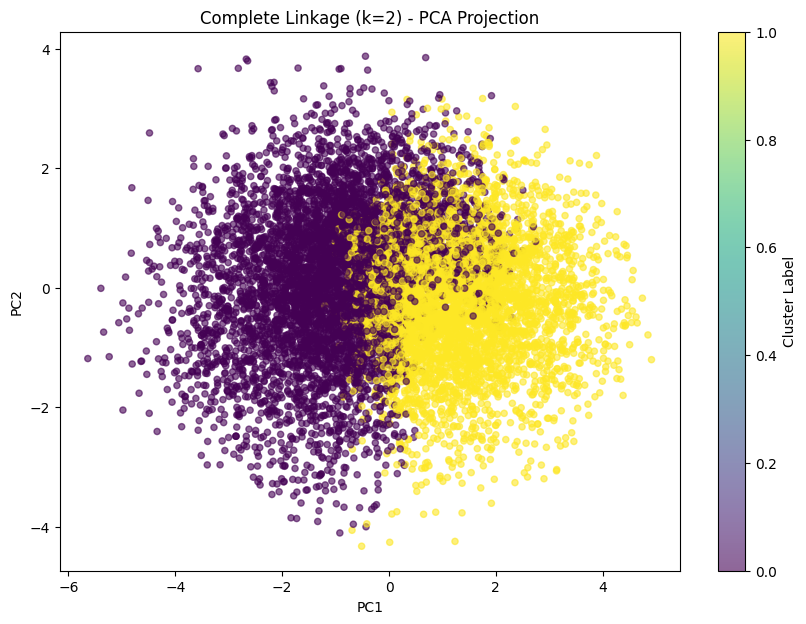


--- CLUSTER PROFILES (Original Scale) ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0        0.123665  23.572184            25.648752  6.002471   32.238882   
1        0.157899  26.189824            30.952947  6.633930   33.851407   

         aggressiveness  
cluster                  
0             -0.246510  
1              0.390205  

--- DEVIATION FROM GLOBAL MEAN ---
         centroid  loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                  
0       -0.015274 -1.167898            -2.366542 -0.281734   -0.719451   
1        0.018960  1.449743             2.937652  0.349724    0.893074   

         aggressiveness  
cluster                  
0             -0.284080  
1              0.352636  


In [12]:
complete_results = analyze_hierarchical_method(X_scaled, X, method='complete')

### Average Linkage

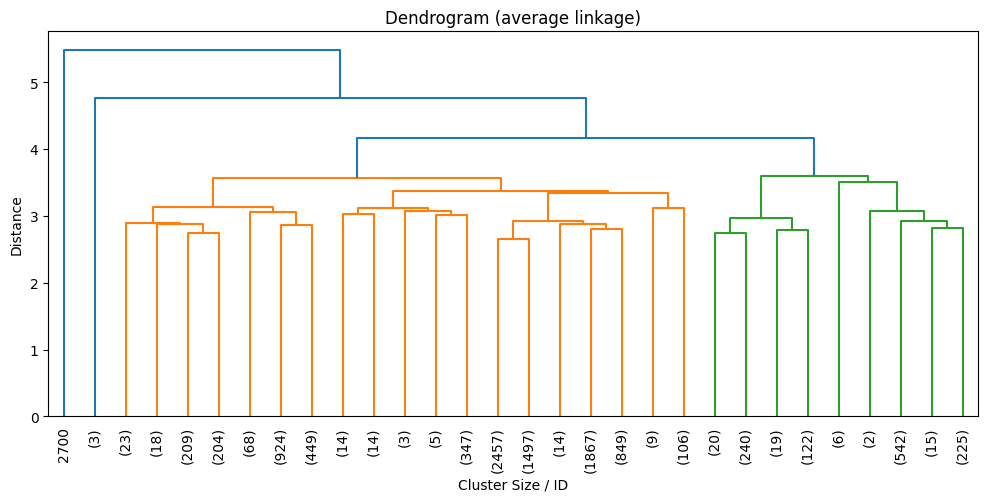


Clustering k = 2:
  Silhouette score = 0.3925
  Cluster 0: 10271 samples
  Cluster 1: 1 samples

Clustering k = 3:
  Silhouette score = 0.2263
  Cluster 0: 10268 samples
  Cluster 1: 1 samples
  Cluster 2: 3 samples

Clustering k = 4:
  Silhouette score = 0.1408
  Cluster 0: 1191 samples
  Cluster 1: 9077 samples
  Cluster 2: 3 samples
  Cluster 3: 1 samples

Clustering k = 5:
  Silhouette score = 0.1060
  Cluster 0: 9077 samples
  Cluster 1: 790 samples
  Cluster 2: 3 samples
  Cluster 3: 1 samples
  Cluster 4: 401 samples

Clustering k = 6:
  Silhouette score = 0.0969
  Cluster 0: 790 samples
  Cluster 1: 7182 samples
  Cluster 2: 1895 samples
  Cluster 3: 1 samples
  Cluster 4: 401 samples
  Cluster 5: 3 samples


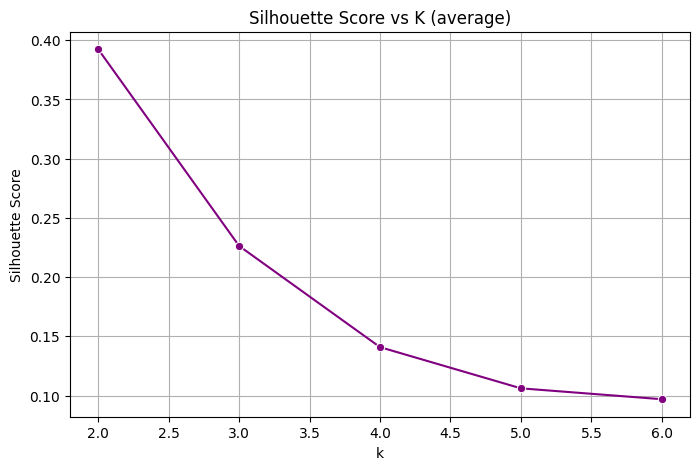

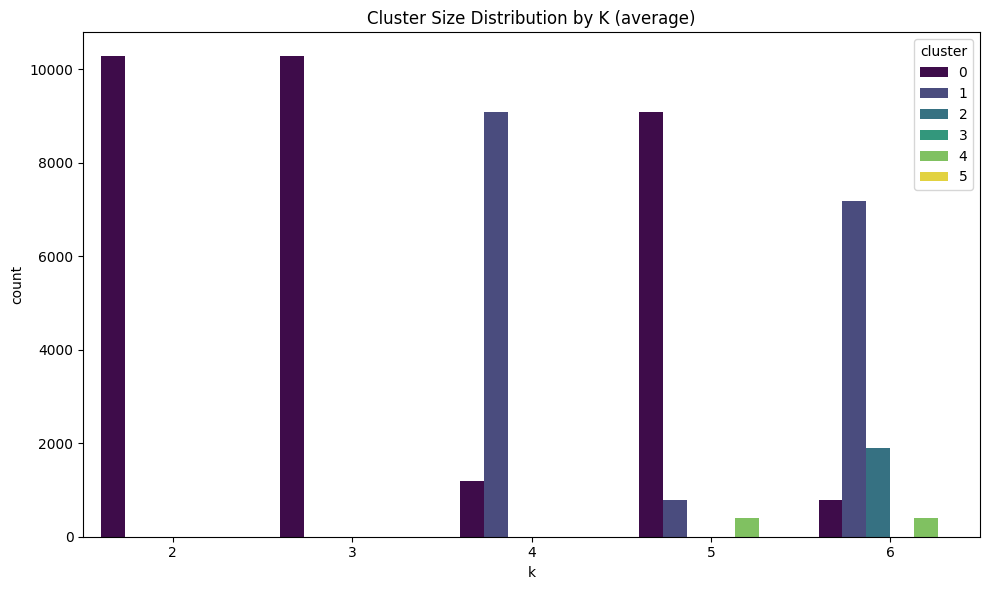


--> BEST CONFIGURATION
Clustering k = 2:
  Silhouette score = 0.3925
  Cluster 0: 10271 samples
  Cluster 1: 1 samples


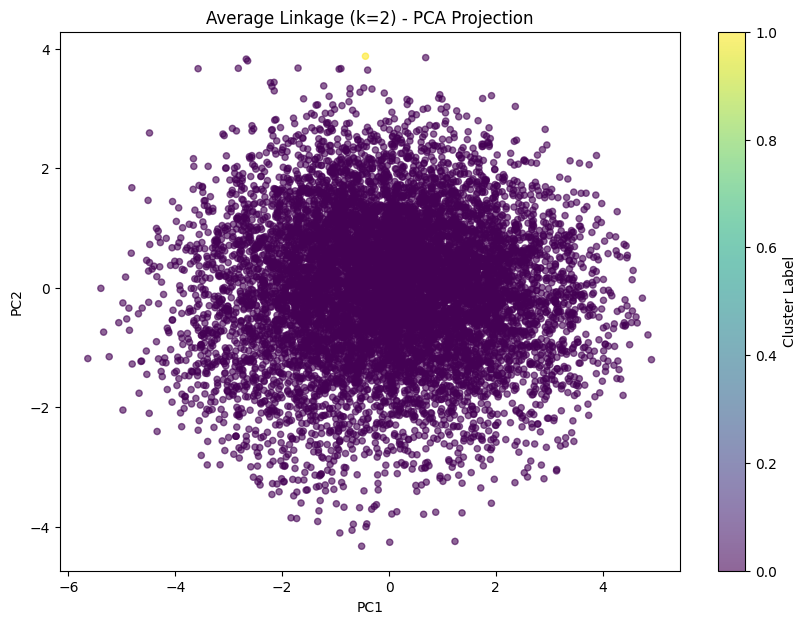


--- CLUSTER PROFILES (Original Scale) ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0        0.138945  24.737942            28.013229  6.284260   32.961055   
1        0.077600  46.717400            49.233200  5.725461    5.000000   

         aggressiveness  
cluster                  
0              0.037617  
1             -0.451525  

--- DEVIATION FROM GLOBAL MEAN ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0        0.000006  -0.002140            -0.002066  0.000054    0.002722   
1       -0.061339  21.977318            21.217905 -0.558745  -27.958333   

         aggressiveness  
cluster                  
0              0.000048  
1             -0.489095  


In [13]:
average_results = analyze_hierarchical_method(X_scaled, X, method='average')